In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load the data:

In [26]:
df = pd.concat([
    pd.read_csv("dronology.csv"),
    pd.read_csv("leeds.csv"),
    pd.read_csv("promise-reclass.csv", quotechar="'"),
    pd.read_csv("reqview.csv"),
    pd.read_csv("wasp.csv")
], keys=["dronology", "leeds", "promise", "reqview", "wasp"], names=["project"]).reset_index(level="project").reset_index(drop=True).reset_index(names="id")

In [27]:
print("Number of instances:", df.shape[0])

Number of instances: 956


In [36]:
df.sample(5)

,id,project,ProjectID,RequirementText,IsFunctional,IsQuality,Class
556,556,promise,8,Customer shall be able to check the status of ...,1,1,PE
189,189,promise,1,The product shall respond fast to keep up-to-d...,0,1,PE
692,692,promise,10,The product shall remove players who have been...,1,0,F
299,299,promise,3,Program Administrators and Nursing Staff Membe...,1,0,F
297,297,promise,3,Program Administrators/Nursing Staff Members s...,1,0,F


In [37]:
df.rename(columns={"RequirementText": "text", "IsFunctional": "label"}, inplace=True)

### Clean the data:

In [38]:
print("Number of missing texts:", df["text"].isnull().sum())

Number of missing texts: 0


In [39]:
print("Number of missing labels:", df["label"].isnull().sum())

Number of missing labels: 0


In [40]:
print(f"Number of duplicated texts: {df["text"].duplicated().sum()} ({df["text"].duplicated().sum()/df.shape[0]:.2%})")

Number of duplicated texts: 3 (0.31%)


### Analyze distributions:

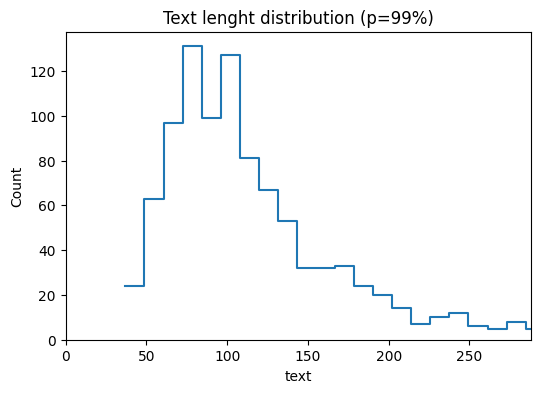

In [41]:
plt.figure(figsize=(6, 4))
sns.histplot(df["text"].str.len(), element="step", fill=False)
plt.xlim([0, df["text"].str.len().quantile(.99)])
plt.title("Text lenght distribution (p=99%)")
plt.show()

In [42]:
df["label"].value_counts(dropna=False, normalize=True).round(2)

label
1    0.6
0    0.4
Name: proportion, dtype: float64

### Persist datasets:

In [43]:
df[["id", "project", "text", "label"]].to_parquet("./functional_requirement.parquet", index=False)

In [44]:
print("Number of instances in the persisted dataset:", df.shape[0])

Number of instances in the persisted dataset: 956
